# ML: Liner Regression - Mobile Price Predictor
---

---
## Data Cleaning
---

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

Firstly,I imported all

In [2]:
df = pd.read_csv("Mobile Phone Price.csv")

Added my dataset to the Project and created a dataframe out of it.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Brand             407 non-null    str  
 1   Model             407 non-null    str  
 2   Storage           407 non-null    str  
 3   RAM               407 non-null    str  
 4   Screen_Size       407 non-null    str  
 5   Camera            407 non-null    str  
 6   Battery_Capacity  407 non-null    int64
 7   Price             407 non-null    int64
dtypes: int64(2), str(6)
memory usage: 25.6 KB


Our data is not null,but we only have 2 columns of numeric type.
In order to predict price we can't fully depend on Battery Capacity alone.

In [4]:
df.head()

,Brand,Model,Storage,RAM,Screen_Size,Camera,Battery_Capacity,Price
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799


Took a look to analyze and took further steps.
 - The 'RAM' and 'Storage' column was needed to be cleaned and converted to a numeric.
  - Screen Size should also be numeric
  - Cameras should also be expanded into further 4 columns so that each camera contributes independently to predict the Price.
  - No need to label Brand and Model as we aren't currently diving into classification models. 

In [5]:
df['Storage']=df['Storage'].str.split("GB").str[0]
df['RAM']=df['RAM'].str.split("GB").str[0]

Starting with first, I cleaned the Storage and RAM column and firstly split the data w.r.t 'GB' it returned a list.I only needed the first element of list.

In [6]:
df['Storage']= pd.to_numeric(df['Storage'], errors='coerce')

After that,I converted the data into numeric via built-in function in Pandas

In [7]:
df['RAM']= pd.to_numeric(df['RAM'], errors='coerce')

Same with RAM

In [8]:
df['Screen_Size']= pd.to_numeric(df['Screen_Size'], errors='coerce')

Secondly, Screen Size

In [9]:
split_data = df['Camera'].str.split('+',expand=True)
split_data.columns = [f'Camera_{i}' for i in split_data.columns]
df = pd.concat([df, split_data], axis=1)
df = df.loc[:, ~df.columns.duplicated()]

Lastly, I cleaned the Camera Column.
 - I Split the data w.r.t '+' sign and created its individual columns with the help of expand parameter.
  - Named each column with the help of a loop.
  - Then, I concatenated the new columns with my actual dataframe.

In [10]:
df['Camera_0']=df['Camera_0'].str.split('MP').str[0]
df['Camera_1']=df['Camera_1'].str.split('MP').str[0]
df['Camera_2']=df['Camera_2'].str.split('MP').str[0]
df['Camera_3']=df['Camera_3'].str.split('MP').str[0]

After further analyzing my data, I caught that some camera are with a keyword 'MP'.
It would create some difficulties where our data about camera will get lost.So, I applied the same topology i used previously while cleaning RAM and Storage columns but this time split it w.r.t 'MP'

In [11]:
df['Camera_0']=pd.to_numeric(df['Camera_0'], errors='coerce')
df['Camera_1']=pd.to_numeric(df['Camera_1'], errors='coerce')
df['Camera_2']=pd.to_numeric(df['Camera_2'], errors='coerce')
df['Camera_3']=pd.to_numeric(df['Camera_3'], errors='coerce')

Then converted it to numeric data type. 

In [12]:
df['RAM'] = df['RAM'].astype(int)
df['Storage'] = df['Storage'].astype(int)

I observed that my data columns RAM and Storage are of float type so i converted it to int.

In [13]:
df = df.fillna(0)

At last, I filled my NaN with zero.
We can drop it due to small dataset, I decided not to.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             407 non-null    str    
 1   Model             407 non-null    str    
 2   Storage           407 non-null    int64  
 3   RAM               407 non-null    int64  
 4   Screen_Size       407 non-null    float64
 5   Camera            407 non-null    str    
 6   Battery_Capacity  407 non-null    int64  
 7   Price             407 non-null    int64  
 8   Camera_0          407 non-null    float64
 9   Camera_1          407 non-null    float64
 10  Camera_2          407 non-null    float64
 11  Camera_3          407 non-null    float64
dtypes: float64(5), int64(4), str(3)
memory usage: 38.3 KB


Now, our data is ready to be fed to model.

We can remove the Camera column,but I decided not to.

In [15]:
df.corr(numeric_only=True)

,Storage,RAM,Screen_Size,Battery_Capacity,Price,Camera_0,Camera_1,Camera_2,Camera_3
Storage,1.000000,0.691341,0.018429,-0.074952,0.711050,0.362034,0.526685,0.556139,0.204599
RAM,0.691341,1.000000,0.058023,-0.027627,0.637172,0.511922,0.534389,0.489217,0.276074
Screen_Size,0.018429,0.058023,1.000000,0.387636,-0.213005,0.239490,0.068705,0.028580,0.153422
Battery_Capacity,-0.074952,-0.027627,0.387636,1.000000,-0.396581,0.289967,-0.115908,-0.045846,0.182662
Price,0.711050,0.637172,-0.213005,-0.396581,1.000000,0.120588,0.628462,0.617568,0.136328
Camera_0,0.362034,0.511922,0.239490,0.289967,0.120588,1.000000,0.151933,0.179320,0.409348
Camera_1,0.526685,0.534389,0.068705,-0.115908,0.628462,0.151933,1.000000,0.453277,0.177013
Camera_2,0.556139,0.489217,0.028580,-0.045846,0.617568,0.179320,0.453277,1.000000,0.177926
Camera_3,0.204599,0.276074,0.153422,0.182662,0.136328,0.409348,0.177013,0.177926,1.000000


Lastly,
This is how we can analyze with column is majorly effecting our price.
In my case, Camera_1 was effecting but that was not realistic.So, Storage and RAM was effecting our price majorly.

---
## Model Building
---

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score,root_mean_squared_error,mean_absolute_percentage_error

I used scikit-learn as its beginner-friendly and easy to setup for my first project.
I am using Linear Regression to train my model.

In [17]:
X = df.drop(["Price","Brand","Model","Camera"],axis=1)
y = df['Price']

Assigned all the columns on which our price depends to X and the attribute which i wanted to get predicted on y.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

Splits the data into Test and Train data.I used the general rule of 20% Test and 80% Train and random state 42 so our both datas don't get mixed each run. 

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Used linear regression and fitted the model on Train Data.

In [20]:
predictions = model.predict(X_test)
print(predictions)

[ 180.63612595  137.69010352  396.99165497  332.62596859  125.29010761
  527.78470439  162.59825271  229.04052805  182.13703747  399.08616284
 1503.33419951  728.11556911  123.74456094  192.4307386   272.86201331
  302.42772904  469.19139255  476.59155807 1187.73423041  302.42772904
  269.51389382 1059.15968502  192.4307386   346.60649526  278.52729765
  248.39150693  997.46232845  300.70211535  343.156666    451.32213516
  357.57452925  476.59155807  799.80478464  299.90405113  228.84492644
  260.25075454  192.4307386   378.49912968  460.025299    658.63017084
  154.61761057  285.07536752  284.50076333  421.88425066  255.6574259
  997.46232845  423.81486815  346.81477388  337.38032164  451.32213516
  193.09931756  628.25922475  192.79649226  446.99410063  395.32387492
  563.61590443  451.32213516  476.59155807  326.26552874  271.34757437
  794.2293424   446.99410063  408.39219222  300.70211535 1013.21512566
  142.10122372  416.55602334 1830.31559827  282.77514964  245.05679719
  190.3

It predicts our price values of the test data.

In [21]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test,predictions)

print(f"MAE:{mae}\nRMSE:{rmse}\nMAPE:{mape}")
print("R2 Score:", r2)

MAE:103.33076606846573
RMSE:157.19189625696293
MAPE:0.2541151121229819
R2 Score: 0.7296099419766436


Here I checked different types of errors which turned out to be good as beginner level models.

In [22]:
sample = [[256, 8, 5.45, 4500,64,12,12,0],[128,6,6.10,3095,12,12,12,0]]

predicted_price = model.predict(sample)

print(predicted_price)


[898.16340068 799.80478464]


C:\Users\HAFZ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


After that I gave data values by myself to get predicted it also done it well.

---
## Graph Plotting
---

In [23]:
import matplotlib.pyplot as plt

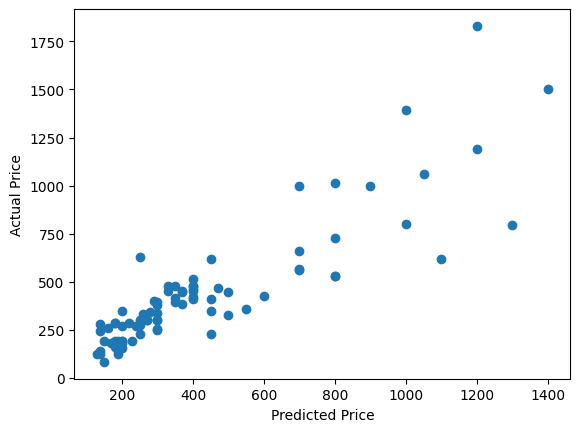

In [24]:
plt.scatter(y_test,predictions)
plt.ylabel("Actual Price")
plt.xlabel('Predicted Price')
plt.show()

## Conclusion

> With this little amount of dataset model is working fine!

I really loved and enjoyed this whole process from cleaning to model training and hope to create more models with linear regression and learn more deep about these stuffs.

**Thank You!** 